**Objective and Problem Statement:** Predict future sales based on factors like advertising spend, target segment and platform.

**Data Loading**

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

#Load the dataset
df = pd.read_csv("Advertising.csv")

#Display the dataset
print(df.head())

Saving Advertising.csv to Advertising.csv
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [ ]:
#Basic Information of Data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [ ]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Features (independent variables)
X = df.drop("Sales", axis=1)

#Target variable
y = df["Sales"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled Features Preview:")
print(X_scaled.head())


Scaled Features Preview:
   Unnamed: 0        TV     Radio  Newspaper
0   -1.723412  0.969852  0.981522   1.778945
1   -1.706091 -1.197376  1.082808   0.669579
2   -1.688771 -1.516155  1.528463   1.783549
3   -1.671450  0.052050  1.217855   1.286405
4   -1.654129  0.394182 -0.841614   1.281802


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
#Select top features based on statistical relationship with target
selector = SelectKBest(score_func=f_regression, k="all")

selector.fit(X_scaled, y)

#Create a dataframe of feature scores
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

#Sort features by importance
feature_scores = feature_scores.sort_values(by="Score", ascending=False)

print("\nFeature Importance Scores:")
print(feature_scores)


Feature Importance Scores:
      Feature       Score
1          TV  312.144994
2       Radio   98.421588
3   Newspaper   10.887299
0  Unnamed: 0    0.528928


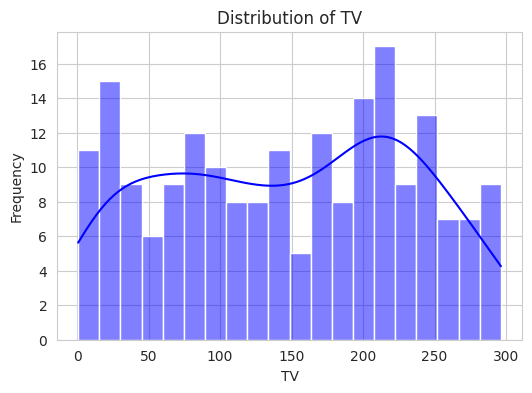

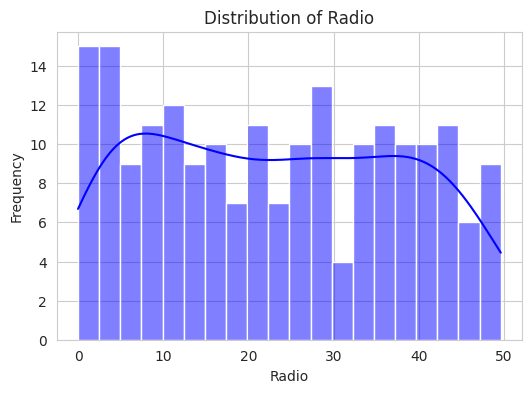

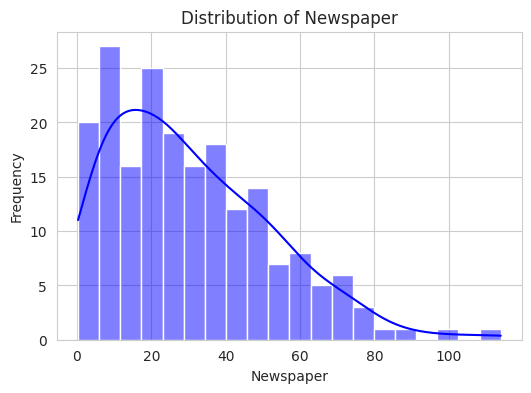

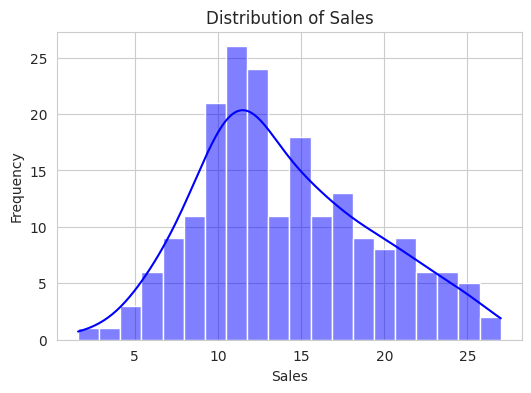

In [ ]:
#Distribution of each feature (Separate Plots)

import matplotlib.pyplot as plt
import seaborn as sns

#List of numerical columns
num_cols = ['TV', 'Radio', 'Newspaper', 'Sales']

#Loop through each column and plot separately
for col in num_cols:
    plt.figure(figsize=(6, 4)) #size for each plot

    sns.histplot(df[col], bins=20, kde=True, color="blue")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

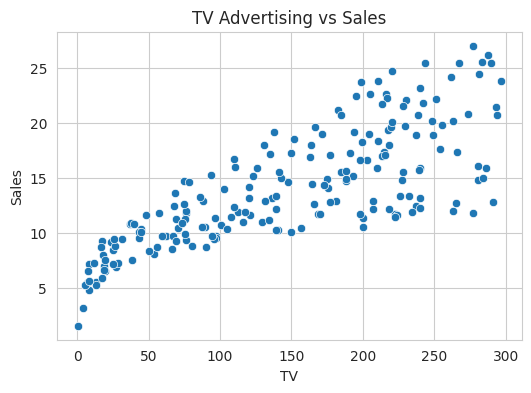

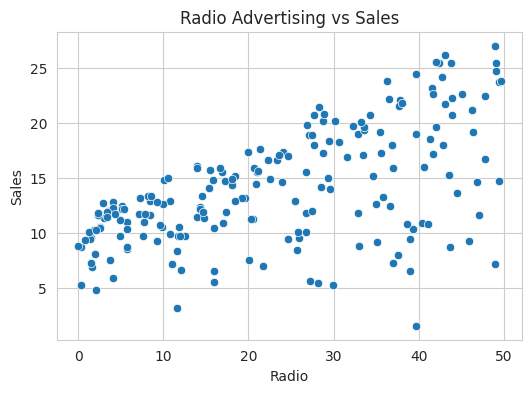

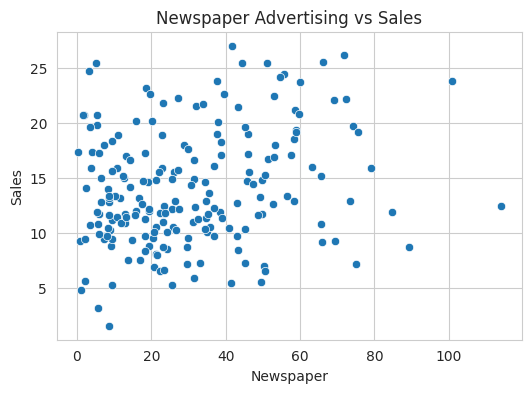

In [ ]:
#Relationship Between Features and Sales

#TV vs Sales
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV Advertising vs Sales")
plt.show()

#Radio vs Sales
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["Radio"], y=df["Sales"])
plt.title("Radio Advertising vs Sales")
plt.show()

#Newspaper vs Sales
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["Newspaper"], y=df["Sales"])
plt.title("Newspaper Advertising vs Sales")
plt.show()

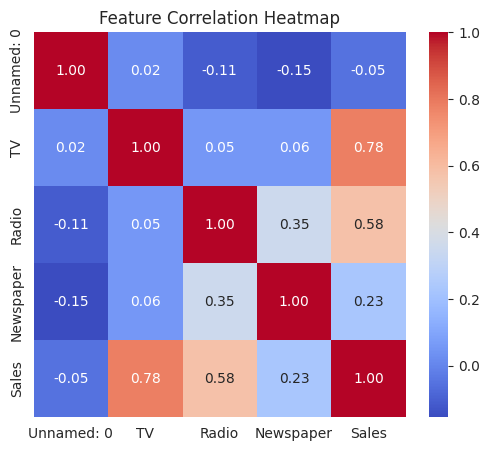

In [ ]:
#Coorelation Analysis
plt.figure(figsize=(6, 5))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


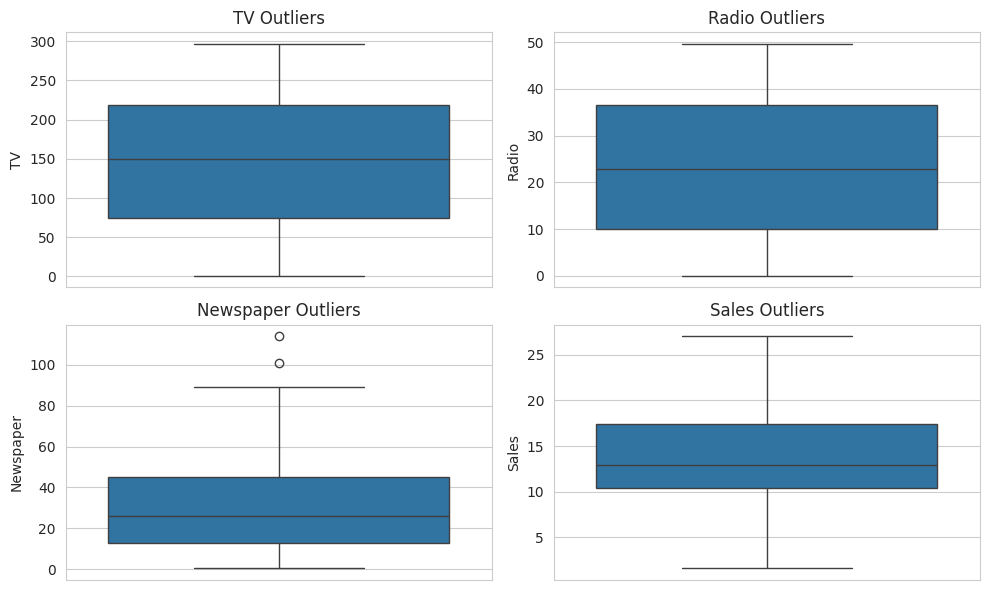

In [ ]:
#Outlier Detection (BoxPlots)
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.boxplot(y=df["TV"])
plt.title("TV Outliers")

plt.subplot(2, 2, 2)
sns.boxplot(y=df["Radio"])
plt.title("Radio Outliers")

plt.subplot(2, 2, 3)
sns.boxplot(y=df["Newspaper"])
plt.title("Newspaper Outliers")

plt.subplot(2, 2, 4)
sns.boxplot(y=df["Sales"])
plt.title("Sales Outliers")

plt.tight_layout()
plt.show()

In [ ]:
#Feature Insight (Average Impact)
print("\nAverage Spending by Channel:")
print(df[["TV", "Radio", "Newspaper"]].mean())

print("\nAverage Sales:", df["Sales"].mean())


Average Spending by Channel:
TV           147.0425
Radio         23.2640
Newspaper     30.5540
dtype: float64

Average Sales: 14.0225


In [ ]:
#Strong Relationship Insight (Quick Check)

print("\nCorrelation with Sales:")
print(df.corr(numeric_only=True)["Sales"].sort_values(ascending=False))


Correlation with Sales:
Sales         1.000000
TV            0.782224
Radio         0.576223
Newspaper     0.228299
Unnamed: 0   -0.051616
Name: Sales, dtype: float64


In [ ]:
#Import all required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Drop unnecessary column if exists
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

#Train Test Split
#Split data into training and testing sets
#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Feature Scaling
#Scaling helps model learn better patterns
scaler = StandardScaler()

#Fit only on training data (IMPORTANT rule)
X_train_scaled = scaler.fit_transform(X_train)

#Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

#Model Building (Regression)
model = LinearRegression()

#Train the model
model.fit(X_train_scaled, y_train)

#Make Predictions
y_pred = model.predict(X_test_scaled)

#Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


📊 MODEL PERFORMANCE
MAE : 1.4650601050102927
MSE : 3.199004468588902
RMSE: 1.788576100865966
R2 Score: 0.8986489151417081


In [ ]:
#Impact using Regression Model
from sklearn.linear_model import LinearRegression

# Features and target
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# Train regression model
model = LinearRegression()
model.fit(X, y)

# Extract coefficients
impact_df = pd.DataFrame({
    "Feature": X.columns,
    "Impact (Coefficient)": model.coef_
})

print("\n📈 Exact Impact of Each Advertising Channel:")
print(impact_df)


📈 Exact Impact of Each Advertising Channel:
     Feature  Impact (Coefficient)
0         TV              0.045765
1      Radio              0.188530
2  Newspaper             -0.001037


The analysis shows that TV advertising has the strongest influence on sales, followed by radio, while newspaper advertising has minimal impact. Businesses should allocate more budget toward high-performing channels like TV and optimize spending on less effective channels. Combining multiple advertising platforms can further enhance sales outcomes. Additionally, predictive models can be used to forecast sales and support data-driven marketing decisions.

The dataset focuses on traditional advertising channels such as TV, radio, and newspaper, which may not fully represent modern digital marketing trends. However, the core concept remains relevant, as advertising investment still drives sales. These traditional channels can be mapped to modern platforms, where TV represents social media ads, radio relates to podcasts and audio ads, and newspaper corresponds to SEO and blog marketing. To make the analysis more realistic, the dataset can be enhanced by including features like Instagram Ads, Google Ads, and Influencer Marketing budgets.
